# IF3170 Artificial Intelligence | Tugas Besar 2

Group Number: 02

Group Members:
- Andhika Maulana Addiputra (18223005)
- Kevin Azra (18223029)
- Arqila Surya Putra (18223047)
- Muhammad Zidni Alkandi (18223071)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import warnings
warnings.filterwarnings("ignore")

# Import other libraries
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    # accuracy_score,
    # precision_score,
    # recall_score,
    # f1_score,
    # confusion_matrix,
    # classification_report,
)

print("Libraries imported successfully!")

Libraries imported successfully!


## Import Dataset

In [2]:

DATA_PATH = 'https://raw.githubusercontent.com/pablonification/tubes-ai2/refs/heads/main/data/'

train_df = pd.read_csv(f"{DATA_PATH}train.csv")
test_df = pd.read_csv(f"{DATA_PATH}test.csv")

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df["is_fraud"].value_counts(normalize=True))

Training set shape: (100000, 31)
Test set shape: (100000, 30)

Target distribution:
is_fraud
0    0.85872
1    0.14128
Name: proportion, dtype: float64


# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.


Train Shape: (100000, 31)
Test Shape: (100000, 30)

INFO: Data types:
int64      15
float64     9
object      7
Name: count, dtype: int64

INFO: Unique values:
ID                        100000
transaction_id            100000
user_id                    28918
age                           62
gender                         2
country                       10
device_type                    3
device_os                      5
merchant_category              9
transaction_amount         28920
transaction_type               4
time_of_day                   24
day_of_week                    7
transaction_duration        2448
num_prev_transactions         49
avg_transaction_amount     14709
std_transaction_amount      7501
transactions_last_24h         45
transactions_last_1h          16
failed_login_attempts          6
ip_risk_score               1001
device_trust_score          1001
account_age_days            2999
has_chargeback_history         2
shared_ip_users               12
shared_device_

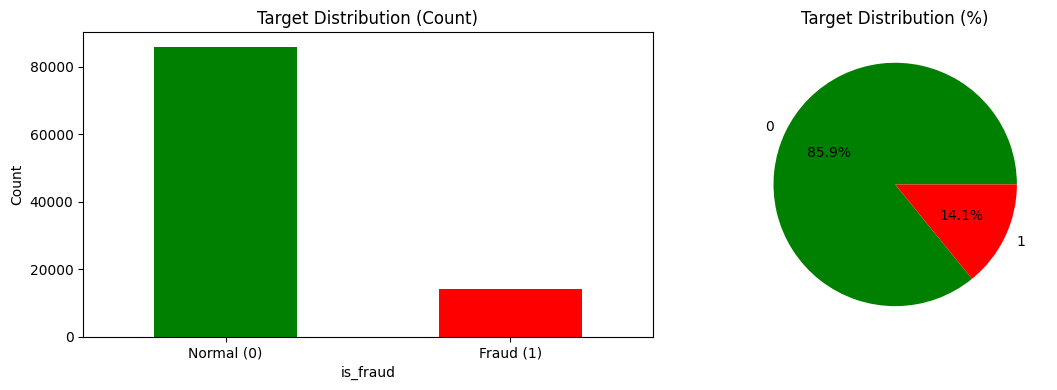



INFO: Missing Values:
missing>>>>>ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
is_fraud                     0
dty

,ID,user_id,age,transaction_amount,time_of_day,day_of_week,transaction_duration,num_prev_transactions,avg_transaction_amount,std_transaction_amount,...,device_trust_score,account_age_days,has_chargeback_history,shared_ip_users,shared_device_users,merchant_risk,country_risk,distance_from_home,is_new_country,is_fraud
count,100000.000000,100000.000000,100000.000000,97581.000000,100000.000000,100000.000000,100000.000000,100000.00000,97581.000000,100000.000000,...,97581.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,49999.500000,15040.173180,48.484150,126.855288,12.770160,2.780700,3.999587,29.99208,69.969722,42.541209,...,0.499480,1497.325540,0.060270,2.000770,1.499800,0.192980,0.071324,117.411584,0.049580,0.141280
std,28867.657797,8655.074007,17.892168,376.035544,5.748626,2.064754,4.012831,5.48621,29.961530,21.652791,...,0.288812,866.004305,0.237988,1.414676,1.225885,0.134019,0.033203,212.016312,0.217077,0.348312
min,0.000000,1.000000,18.000000,0.010000,0.000000,0.000000,0.000000,8.00000,-52.890000,5.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.050000,0.020000,0.000000,0.000000,0.000000
25%,24999.750000,7549.000000,33.000000,26.910000,8.000000,1.000000,1.150000,26.00000,49.780000,23.860000,...,0.249000,745.000000,0.000000,1.000000,1.000000,0.080000,0.040000,29.620000,0.000000,0.000000
50%,49999.500000,15093.000000,48.000000,64.460000,12.000000,3.000000,2.760000,30.00000,69.990000,42.480000,...,0.499000,1496.000000,0.000000,2.000000,1.000000,0.120000,0.050000,71.810000,0.000000,0.000000
75%,74999.250000,22541.000000,64.000000,131.060000,18.000000,5.000000,5.540000,34.00000,90.250000,61.310000,...,0.750000,2244.000000,0.000000,3.000000,2.000000,0.300000,0.100000,144.440000,0.000000,0.000000
max,99999.000000,29999.000000,79.000000,20601.133350,23.000000,6.000000,52.070000,59.00000,195.790000,80.000000,...,1.000000,2999.000000,1.000000,11.000000,11.000000,0.550000,0.130000,6388.517628,1.000000,1.000000


In [3]:
# Basic Info
print("="*60)
print(f"\nTrain Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")

print("\nINFO: Data types:")
print(train_df.dtypes.value_counts())

print("\nINFO: Unique values:")
print(train_df.nunique())

print("\nINFO: Describe:")
print(train_df.describe())

# Target Distribution
print("\n" + "="*60)
print("\nINFO: Target Distribution (is_fraud):")
target_counts = train_df['is_fraud'].value_counts()
print(f"target_counts>>>>{target_counts}")

target_pct = train_df['is_fraud'].value_counts(normalize=True) * 100
print(f"target_pct>>>>{target_pct}")

print(f"\nClass 0 (Normal): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Class 1 (Fraud):  {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nImbalance Ratio: {target_counts[0]/target_counts[1]:.2f}:1")

# Visualisasi
fig, ax = plt.subplots(1,2, figsize=(12,4))
target_counts.plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Target Distribution (Count)')
ax[0].set_xlabel('is_fraud')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
target_pct.plot(kind='pie', ax=ax[1], autopct='%.1f%%', colors=['green', 'red'])
ax[1].set_title('Target Distribution (%)')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

# missing values
print("\n" + "="*60)
print("\nINFO: Missing Values:")

missing = train_df.isnull().sum()
print(f"missing>>>>>{missing}")

missing_pct = (missing / len(train_df)) * 100
print(f"missing_pct>>>>>{missing_pct}")

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).sort_values('Missing Count', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(f"\nColumns with missing values: {len(missing_df)}")
    print(missing_df)
else:
    print("\nNo missing values found!")

# Numeric Features
print("\n" + "="*60)
print("\nINFO: Numeric Features:")
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print("\nStatistics:")
train_df[numeric_cols].describe()


# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [4]:
# Store test ID for submission
test_ids = test_df["ID"].values

# Split training data for validation in this machine
X_full = train_df.drop(columns=["is_fraud"])
y_full = train_df["is_fraud"].values

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"Training set: {X_train_raw.shape}")
print(f"Validation set: {X_val_raw.shape}")
print(f"Test set: {test_df.shape}")

Training set: (80000, 30)
Validation set: (20000, 30)
Test set: (100000, 30)


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureImputer(BaseEstimator, TransformerMixin):
    """
    Transformer dari sklearn ini digunakan untuk menangani nilai yang hilang dalam data.
    - Numeric columns: fill with median -> karna ada outlier dan untuk preserve distribusi datanya
    - Categorical columns: fill with mode -> memperlihatakan seberapa banyak
    """
    
    def __init__(self):
        self.medians_ = {}
        self.modes_ = {}
        self.numeric_cols_ = []
        self.categorical_cols_ = []
    
    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Identify column types
        self.numeric_cols_ = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols_ = df.select_dtypes(include=["object"]).columns.tolist()
        
        # Exclude ID columns from imputation
        id_cols = ["ID", "transaction_id", "user_id"]
        self.numeric_cols_ = [c for c in self.numeric_cols_ if c not in id_cols]
        
        # Compute medians for numeric columns
        for col in self.numeric_cols_:
            self.medians_[col] = df[col].median()
        
        # Compute modes for categorical columns
        for col in self.categorical_cols_:
            self.modes_[col] = df[col].mode()[0] if len(df[col].mode()) > 0 else "Unknown"
        
        return self
    
    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Fill numeric columns with median
        for col in self.numeric_cols_:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians_.get(col, 0))
        
        # Fill categorical columns with mode
        for col in self.categorical_cols_:
            if col in df.columns:
                df[col] = df[col].fillna(self.modes_.get(col, "Unknown"))
        
        return df


# Apply imputation
imputer = FeatureImputer()
train_df_clean = imputer.fit_transform(train_df)
test_df_clean = imputer.transform(test_df)

print("Missing values after cleaning:")
print(f"Train: {train_df_clean.isnull().sum().sum()}")
print(f"Test: {test_df_clean.isnull().sum().sum()}")

Missing values after cleaning:
Train: 0
Test: 0


### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [6]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    """
    Menggunakan transformer yang sama untuk handling outliers via CLIPPING -> mengganti outlier dengan batas yg ditentukan instead of ngapus
    Pake IQR = Q3 - Q1
    """
    
    def __init__(self, clip_cols=None, clip_bounds=None):
        # Specific columns and their clip bounds
        self.clip_cols = clip_cols or []
        self.clip_bounds = clip_bounds or {}
        self.computed_bounds_ = {}
    
    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # For columns without predefined bounds, compute IQR-based bounds
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        id_cols = ["ID", "transaction_id", "user_id", "is_fraud"]
        numeric_cols = [c for c in numeric_cols if c not in id_cols]
        
        for col in numeric_cols:
            if col not in self.clip_bounds:
                Q1 = df[col].quantile(0.01)
                Q3 = df[col].quantile(0.99)
                self.computed_bounds_[col] = (Q1, Q3)
        
        return self
    
    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Apply predefined bounds
        for col, (lower, upper) in self.clip_bounds.items():
            if col in df.columns:
                df[col] = df[col].clip(lower, upper)
        # IQR baru dilakukan pada feature engineering agar original behavior tetap terjaga
        
        return df


# Define explicit outlier handling bounds
# These are applied during feature engineering to specific derived features
outlier_bounds = {
    "amount_zscore": (-10, 10),
    "amount_ratio": (0, 100),
}

outlier_handler = OutlierHandler(clip_bounds=outlier_bounds)
print("Outlier handling configured:")
print(f"  - amount_zscore: clipped to [-10, 10]")
print(f"  - amount_ratio: clipped to [0, 100]")
print("Outliers in derived features will be clipped during feature engineering.")

Outlier handling configured:
  - amount_zscore: clipped to [-10, 10]
  - amount_ratio: clipped to [0, 100]
Outliers in derived features will be clipped during feature engineering.


### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [7]:
print(f"Duplicates in train: {train_df_clean.duplicated().sum()}")
print(f"Duplicates in test: {test_df_clean.duplicated().sum()}")
# gaperlu karna gaada

Duplicates in train: 0
Duplicates in test: 0


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [8]:
class FeatureCreator(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.quantiles_ = {}
    
    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Compute quantiles from training data only (prevent data leakage)
        self.quantiles_ = {
            "distance_q75": df["distance_from_home"].quantile(0.75),
            "amount_q90": df["transaction_amount"].quantile(0.90),
        }
        
        return self
    
    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Amount features
        std_val = df["std_transaction_amount"].replace(0, 1)
        df["amount_zscore"] = (
            (df["transaction_amount"] - df["avg_transaction_amount"]) / std_val
        ).clip(-10, 10)  # Outlier clipping
        df["amount_ratio"] = (
            df["transaction_amount"] / (df["avg_transaction_amount"] + 1)
        ).clip(0, 100)  # Outlier clipping

        # Velocity features
        df["high_velocity_2"] = (df["transactions_last_1h"] >= 2).astype(int) # astype is assigning datatype to int
        df["high_velocity_3"] = (df["transactions_last_1h"] >= 3).astype(int)

        # Risk features
        df["risk_sum"] = df["ip_risk_score"] + df["merchant_risk"] + df["country_risk"]
        df["risk_weighted"] = df["ip_risk_score"] * (1 - df["device_trust_score"] + 0.01)
        df["final_risk_score_v2"] = (
            df["ip_risk_score"] * 0.4
            + df["merchant_risk"] * 0.3
            + (1 - df["device_trust_score"]) * 0.3
        )

        # Location/account features
        df["far_from_home"] = (df["distance_from_home"] > self.quantiles_["distance_q75"]).astype(int)
        df["account_new"] = (df["account_age_days"] < 30).astype(int)

        # Log features
        df["log_transaction_amount"] = np.log1p(df["transaction_amount"]) # log1p(x) = hitung log(1+x); lebih aman dari log(x) karena x bisa 0 -> log(0) = -inf
        df["log_distance"] = np.log1p(df["distance_from_home"])

        # Interaction features
        df["risk_x_amount"] = df["ip_risk_score"] * df["amount_ratio"]
        df["velocity_x_risk"] = df["transactions_last_1h"] * df["ip_risk_score"]
        df["age_inv_x_risk"] = df["ip_risk_score"] / (df["account_age_days"] + 1)
        df["distance_x_newcountry"] = df["distance_from_home"] * df["is_new_country"]
        df["trust_deficit"] = (1 - df["device_trust_score"]) * df["ip_risk_score"]
        df["shared_resource_score"] = df["shared_ip_users"] + df["shared_device_users"]

        # Tier features
        df["high_amount"] = (df["transaction_amount"] > self.quantiles_["amount_q90"]).astype(int)
        df["risk_tier_high"] = (df["risk_sum"] > 1.5).astype(int)
        df["risk_tier_extreme"] = (df["risk_sum"] > 2.0).astype(int)

        return df


# Apply feature engineering
feature_creator = FeatureCreator()
train_fe = feature_creator.fit_transform(train_df_clean)
test_fe = feature_creator.transform(test_df_clean)

print(f"Features after engineering: {train_fe.shape[1]}")
print(f"New features created: 19")

Features after engineering: 51
New features created: 19


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

### I. Feature Scaling & II. Feature Encoding

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

---

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [9]:
class FeatureEncoder(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for one-hot encoding categorical features.
    """

    def __init__(self):
        self.encoded_columns_ = None
        self.cat_cols_ = []
        self.id_cols_to_drop = ["ID", "transaction_id", "user_id"]

    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        
        # Drop ID columns before identifying categorical columns for encoding
        df_processed = df.drop(columns=[col for col in self.id_cols_to_drop if col in df.columns], errors='ignore')

        # Identify categorical columns
        self.cat_cols_ = df_processed.select_dtypes(include=["object"]).columns.tolist()

        # Perform one-hot encoding to get column names
        df_encoded = pd.get_dummies(df_processed, columns=self.cat_cols_, drop_first=False)
        self.encoded_columns_ = df_encoded.columns.tolist()

        return self

    def transform(self, X):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        # Drop ID columns in transform as well
        df_processed = df.drop(columns=[col for col in self.id_cols_to_drop if col in df.columns], errors='ignore')

        # One-hot encode
        df = pd.get_dummies(df_processed, columns=self.cat_cols_, drop_first=False)

        # Align columns with training data
        for col in self.encoded_columns_:
            if col not in df.columns:
                df[col] = 0

        # Keep only columns from training
        df = df[[c for c in self.encoded_columns_ if c in df.columns]]

        return df


class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for selecting specific features.
    """

    def __init__(self, features):
        self.features = features
        self.available_features_ = []

    def fit(self, X, y=None):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.available_features_ = [f for f in self.features if f in df.columns]
        return self

    def transform(self, X):
        df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

        # Select available features
        result = df[self.available_features_].copy()

        # Convert to numpy and handle NaN/Inf
        arr = result.values.astype(np.float64)
        arr = np.nan_to_num(arr, nan=0, posinf=0, neginf=0)

        return arr


class FeatureScaler(BaseEstimator, TransformerMixin):
    """
    Sklearn-compatible transformer for StandardScaler.
    """

    def __init__(self):
        self.scaler_ = StandardScaler()

    def fit(self, X, y=None):
        self.scaler_.fit(X)
        return self

    def transform(self, X):
        return self.scaler_.transform(X)


# Define feature sets
FEATURES_27 = [  # For Decision Tree
    "transaction_amount",
    "amount_zscore",
    "avg_transaction_amount",
    "std_transaction_amount",
    "amount_ratio",
    "transactions_last_24h",
    "transactions_last_1h",
    "high_velocity_2",
    "high_velocity_3",
    "ip_risk_score",
    "device_trust_score",
    "merchant_risk",
    "risk_sum",
    "risk_weighted",
    "final_risk_score_v2",
    "distance_from_home",
    "far_from_home",
    "is_new_country",
    "account_age_days",
    "account_new",
    "has_chargeback_history",
    "shared_ip_users",
    "shared_device_users",
    "failed_login_attempts",
    "device_type_desktop",
    "device_type_mobile",
    "device_type_tablet",
]

FEATURES_38 = FEATURES_27 + [  # For Logistic Regression
    "log_transaction_amount",
    "log_distance",
    "risk_x_amount",
    "velocity_x_risk",
    "age_inv_x_risk",
    "distance_x_newcountry",
    "trust_deficit",
    "shared_resource_score",
    "high_amount",
    "risk_tier_high",
    "risk_tier_extreme",
]

# Apply encoding
encoder = FeatureEncoder()
train_encoded = encoder.fit_transform(train_fe)
test_encoded = encoder.transform(test_fe)

# Extract target
y = train_df["is_fraud"].values

# Select features for DT (27 features)
selector_dt = FeatureSelector(FEATURES_27)
X_27 = selector_dt.fit_transform(train_encoded)
X_test_27 = selector_dt.transform(test_encoded)

# Select features for LR (38 features)
selector_lr = FeatureSelector(FEATURES_38)
X_38 = selector_lr.fit_transform(train_encoded)
X_test_38 = selector_lr.transform(test_encoded)

print(f"DT features: {X_27.shape[1]} (target: 27)")
print(f"LR features: {X_38.shape[1]} (target: 38)")

# Scale LR features
scaler = FeatureScaler()
X_38_scaled = scaler.fit_transform(X_38)
X_test_38_scaled = scaler.transform(X_test_38)

print("\nData preparation complete!")

DT features: 27 (target: 27)
LR features: 38 (target: 38)

Data preparation complete!


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [10]:
# Class distribution analysis
class_counts = np.bincount(y)
class_ratio = class_counts[0] / class_counts[1]

print(f"Class distribution:")
print(f"  Class 0 (Normal): {class_counts[0]:,} ({class_counts[0]/len(y)*100:.2f}%)")
print(f"  Class 1 (Fraud):  {class_counts[1]:,} ({class_counts[1]/len(y)*100:.2f}%)")
print(f"  Imbalance ratio: {class_ratio:.2f}:1")

print("\n" + "="*60)
print("HANDLING IMBALANCED DATA: PROBABILITY CALIBRATION")
print("="*60)
"""
Disini dipakai PROBABILITY CALIBRATION instead of resampling karna:
1. Menjaga distribusi data asli - tidak ada synthetic samples
2. Meningkatkan estimasi probabilitas untuk kelas minoritas (fraud)
3. Cocok dengan metrik AUC-ROC yang digunakan dalam Kaggle
4. Mengurangi prediksi yang overconfident pada kelas mayoritas

Methods Used:
- Logistic Regression: Sigmoid (Platt) Calibration with CV=4
- Decision Tree: Isotonic Calibration with CV=5

Keduanya di implementasi dari scratch dengan:
- SigmoidCalibrationScratch: L-BFGS optimization for Platt scaling
- IsotonicRegressionScratch: Pool Adjacent Violators Algorithm (PAVA)
- CalibratedClassifierCVScratch: Cross-validation wrapper
"""

Class distribution:
  Class 0 (Normal): 85,872 (85.87%)
  Class 1 (Fraud):  14,128 (14.13%)
  Imbalance ratio: 6.08:1

HANDLING IMBALANCED DATA: PROBABILITY CALIBRATION


'\nDisini dipakai PROBABILITY CALIBRATION instead of resampling karna:\n1. Menjaga distribusi data asli - tidak ada synthetic samples\n2. Meningkatkan estimasi probabilitas untuk kelas minoritas (fraud)\n3. Cocok dengan metrik AUC-ROC yang digunakan dalam Kaggle\n4. Mengurangi prediksi yang overconfident pada kelas mayoritas\n\nMethods Used:\n- Logistic Regression: Sigmoid (Platt) Calibration with CV=4\n- Decision Tree: Isotonic Calibration with CV=5\n\nKeduanya di implementasi dari scratch dengan:\n- SigmoidCalibrationScratch: L-BFGS optimization for Platt scaling\n- IsotonicRegressionScratch: Pool Adjacent Violators Algorithm (PAVA)\n- CalibratedClassifierCVScratch: Cross-validation wrapper\n'

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [11]:
# dipakai untuk logreg dan dilakukan Scaling dengan StandardScaler; udah dilakukan di feature scaling
print("Already done in feature scaling")

Already done in feature scaling


### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [12]:
# Write your code here

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [13]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

# Pipeline for Decision Tree (no scaling needed)
from sklearn.pipeline import Pipeline

pipeline_dt = Pipeline([
    ("imputer", FeatureImputer()),
    ("feature_creator", FeatureCreator()),
    ("encoder", FeatureEncoder()),
    ("selector", FeatureSelector(FEATURES_27)),
])

# Pipeline for Logistic Regression (with scaling)
pipeline_lr = Pipeline([
    ("imputer", FeatureImputer()),
    ("feature_creator", FeatureCreator()),
    ("encoder", FeatureEncoder()),
    ("selector", FeatureSelector(FEATURES_38)),
    ("scaler", FeatureScaler()),
])

# Fit and transform using pipelines
X_dt = pipeline_dt.fit_transform(train_df)
X_test_dt = pipeline_dt.transform(test_df)

X_lr = pipeline_lr.fit_transform(train_df)
X_test_lr = pipeline_lr.transform(test_df)

print("Preprocessing pipelines compiled and applied!")
print(f"Pipeline DT output shape: {X_dt.shape}")
print(f"Pipeline LR output shape: {X_lr.shape}")

# Verify consistency with manual preprocessing
print(f"\nVerification:")
print(f"  DT features match: {np.allclose(X_dt, X_27)}")
print(f"  LR features match: {np.allclose(X_lr, X_38_scaled)}")

Preprocessing pipelines compiled and applied!
Pipeline DT output shape: (100000, 27)
Pipeline LR output shape: (100000, 38)

Verification:
  DT features match: True
  LR features match: True


In [14]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [15]:
# Type your code here

## B. Logistic Regression

In [16]:
class IsotonicRegressionScratch:
    """
    Isotonic Regression menggunakan Pool Adjacent Violators Algorithm (PAVA).
    Digunakan untuk probability calibration.
    """

    def __init__(self, out_of_bounds="clip"):
        self.out_of_bounds = out_of_bounds
        self.X_thresholds_ = None
        self.y_thresholds_ = None
        self.X_min_, self.X_max_ = None, None
        self.y_min_, self.y_max_ = None, None

    def fit(self, X, y, sample_weight=None):
        """Fit isotonic regression using PAVA algorithm."""
        X = np.asarray(X, dtype=np.float64).ravel()
        y = np.asarray(y, dtype=np.float64).ravel()

        if sample_weight is None:
            sample_weight = np.ones(len(X))

        # Sort by X
        order = np.argsort(X)
        X, y = X[order], y[order]
        sample_weight = sample_weight[order]

        # PAVA algorithm
        n = len(y)
        weighted_y = y * sample_weight

        blocks = [
            {
                "start": i,
                "end": i + 1,
                "sum_wy": weighted_y[i],
                "sum_w": sample_weight[i],
                "value": y[i],
            }
            for i in range(n)
        ]

        i = 0
        while i < len(blocks) - 1:
            if blocks[i]["value"] > blocks[i + 1]["value"]:
                # Merge blocks
                blocks[i]["end"] = blocks[i + 1]["end"]
                blocks[i]["sum_wy"] += blocks[i + 1]["sum_wy"]
                blocks[i]["sum_w"] += blocks[i + 1]["sum_w"]
                blocks[i]["value"] = blocks[i]["sum_wy"] / blocks[i]["sum_w"]
                blocks.pop(i + 1)
                if i > 0:
                    i -= 1
            else:
                i += 1

        # Build thresholds
        self.X_thresholds_, self.y_thresholds_ = [], []
        for block in blocks:
            for x_val in X[block["start"] : block["end"]]:
                self.X_thresholds_.append(x_val)
                self.y_thresholds_.append(block["value"])

        self.X_thresholds_ = np.array(self.X_thresholds_)
        self.y_thresholds_ = np.array(self.y_thresholds_)

        # Remove duplicates
        unique_mask = np.concatenate([[True], np.diff(self.X_thresholds_) > 0])
        self.X_thresholds_ = self.X_thresholds_[unique_mask]
        self.y_thresholds_ = self.y_thresholds_[unique_mask]

        self.X_min_, self.X_max_ = self.X_thresholds_[0], self.X_thresholds_[-1]
        self.y_min_, self.y_max_ = self.y_thresholds_[0], self.y_thresholds_[-1]

        return self

    def predict(self, X):
        """Predict using linear interpolation."""
        X = np.asarray(X, dtype=np.float64).ravel()
        y_pred = np.interp(X, self.X_thresholds_, self.y_thresholds_)

        if self.out_of_bounds == "clip":
            y_pred = np.clip(y_pred, self.y_min_, self.y_max_)

        return np.clip(y_pred, 0.0, 1.0)


class SigmoidCalibrationScratch:
    """
    Sigmoid (Platt) Kalibrasi menggunakan L-BFGS optimization yg dibuat dari scratch.
    Cocok untuk: P(y=1|f) = 1 / (1 + exp(-(A*f + B)))
    """

    def __init__(self, max_iter=1000, tol=1e-7):
        self.max_iter = max_iter
        self.tol = tol
        self.A_, self.B_ = None, None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y, sample_weight=None):
        # Fit sigmoid calibration using L-BFGS.
        X = np.asarray(X, dtype=np.float64).ravel()
        y = np.asarray(y, dtype=np.float64).ravel()
        n = len(y)

        if sample_weight is None:
            sample_weight = np.ones(n)

        # Platt's targets
        n_pos, n_neg = np.sum(y == 1), n - np.sum(y == 1)
        t_pos = (n_pos + 1.0) / (n_pos + 2.0)
        t_neg = 1.0 / (n_neg + 2.0)
        T = np.where(y == 1, t_pos, t_neg)

        # Initialize
        A = 0.0
        B = np.log((n_neg + 1.0) / (n_pos + 1.0))

        def objective_and_gradient(params):
            A_val, B_val = params
            p = self._sigmoid(A_val * X + B_val)
            p = np.clip(p, 1e-15, 1 - 1e-15)
            loss = -np.sum(sample_weight * (T * np.log(p) + (1 - T) * np.log(1 - p)))
            error = p - T
            dA = np.sum(sample_weight * error * X)
            dB = np.sum(sample_weight * error)
            return loss, np.array([dA, dB])

        def line_search(params, direction, grad, loss, max_iter=20):
            c1, alpha, rho = 1e-4, 1.0, 0.5
            directional_deriv = np.dot(grad, direction)
            for _ in range(max_iter):
                new_params = params + alpha * direction
                new_loss, _ = objective_and_gradient(new_params)
                if new_loss <= loss + c1 * alpha * directional_deriv:
                    return alpha, new_params, new_loss
                alpha *= rho
            return (
                alpha,
                params + alpha * direction,
                objective_and_gradient(params + alpha * direction)[0],
            )

        def lbfgs_two_loop(grad, s_hist, y_hist, rho_hist):
            q = grad.copy()
            m_curr = len(s_hist)
            if m_curr == 0:
                return -grad
            alpha_arr = np.zeros(m_curr)
            for i in range(m_curr - 1, -1, -1):
                alpha_arr[i] = rho_hist[i] * np.dot(s_hist[i], q)
                q = q - alpha_arr[i] * y_hist[i]
            gamma = np.dot(s_hist[-1], y_hist[-1]) / (
                np.dot(y_hist[-1], y_hist[-1]) + 1e-10
            )
            r = gamma * q
            for i in range(m_curr):
                beta = rho_hist[i] * np.dot(y_hist[i], r)
                r = r + (alpha_arr[i] - beta) * s_hist[i]
            return -r

        # L-BFGS optimization
        params = np.array([A, B])
        m = 10
        s_history, y_history, rho_history = [], [], []
        loss, grad = objective_and_gradient(params)

        for _ in range(self.max_iter):
            direction = lbfgs_two_loop(grad, s_history, y_history, rho_history)
            alpha, new_params, new_loss = line_search(params, direction, grad, loss)
            _, new_grad = objective_and_gradient(new_params)

            s, y_vec = new_params - params, new_grad - grad
            if np.linalg.norm(new_grad) < self.tol:
                params = new_params
                break

            sy = np.dot(s, y_vec)
            if sy > 1e-10:
                if len(s_history) >= m:
                    s_history.pop(0)
                    y_history.pop(0)
                    rho_history.pop(0)
                s_history.append(s)
                y_history.append(y_vec)
                rho_history.append(1.0 / sy)

            params, loss, grad = new_params, new_loss, new_grad

        self.A_, self.B_ = params[0], params[1]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64).ravel()
        return np.clip(self._sigmoid(self.A_ * X + self.B_), 0.0, 1.0)


class CalibratedClassifierCVScratch:
    """
    Probability calibration dengan cross-validation yg dibuat dari scratch.
    Implementasi sama seperti sklearn's CalibratedClassifierCV.
    """

    def __init__(self, base_estimator, method="sigmoid", cv=5, random_state=None):
        self.base_estimator = base_estimator
        self.method = method
        self.cv = cv
        self.random_state = random_state
        self.calibrated_classifiers_ = []
        self.classes_ = None

    def _get_calibrator(self):
        if self.method == "sigmoid":
            return SigmoidCalibrationScratch(max_iter=1000, tol=1e-7)
        elif self.method == "isotonic":
            return IsotonicRegressionScratch(out_of_bounds="clip")
        else:
            raise ValueError(f"Unknown method: {self.method}")

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.calibrated_classifiers_ = []

        cv = StratifiedKFold(
            n_splits=self.cv, shuffle=True, random_state=self.random_state
        )

        for train_idx, val_idx in cv.split(X, y):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            model = deepcopy(self.base_estimator)
            model.fit(X_train, y_train)

            val_proba = model.predict_proba(X_val)[:, 1]

            calibrator = self._get_calibrator()
            calibrator.fit(val_proba, y_val)

            self.calibrated_classifiers_.append((model, calibrator))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        all_proba = []

        for model, calibrator in self.calibrated_classifiers_:
            raw_proba = model.predict_proba(X)[:, 1]
            calibrated_proba = calibrator.predict(raw_proba)
            all_proba.append(calibrated_proba)

        mean_proba_1 = np.mean(all_proba, axis=0)
        return np.column_stack([1 - mean_proba_1, mean_proba_1])

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


print("All calibration classes defined!")

All calibration classes defined!


In [17]:
class LogisticRegressionScratch:
    """
    Logistic Regression implemented from scratch pake L-BFGS optimization.

    Features:
    - L-BFGS optimizer with two-loop recursion
    - L2 regularization (scaled by n_samples to match sklearn)
    - Numerically stable sigmoid
    """

    def __init__(
        self,
        max_iter=200,
        tol=1e-6,
        C=1.0,
        regularization="l2",
        random_state=None,
        verbose=False,
    ):
        self.max_iter = max_iter
        self.tol = tol
        self.C = C
        self.regularization = regularization
        self.random_state = random_state
        self.verbose = verbose
        self.weights_ = None
        self.bias_ = None
        self.classes_ = None
        self.loss_history_ = []

    def _sigmoid(self, z): # Numerically stable sigmoid
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _fit_lbfgs(self, X, y): # L-BFGS optimization from scratch
        n_samples, n_features = X.shape
        m = 10  # Memory size

        # L-BFGS history
        s_history, y_history, rho_history = [], [], []

        # Initialize parameters
        params = np.concatenate([self.weights_, [self.bias_]])

        def objective_and_gradient(params):
            w, b = params[:-1], params[-1]

            # Forward pass
            z = X @ w + b
            y_pred = self._sigmoid(z)
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

            # Loss (BCE + L2 regularization scaled by n_samples)
            bce = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            reg_term = (
                (1 / (2 * self.C * n_samples)) * np.sum(w**2)
                if self.regularization == "l2"
                else 0
            )
            loss = bce + reg_term

            # Gradient
            error = y_pred - y
            dw = (X.T @ error) / n_samples
            if self.regularization == "l2":
                dw += (1 / (self.C * n_samples)) * w
            db = np.mean(error)

            return loss, np.concatenate([dw, [db]])

        def lbfgs_two_loop(grad, s_hist, y_hist, rho_hist): # L-BFGS two-loop recursion
            q = grad.copy()
            m_curr = len(s_hist)

            if m_curr == 0:
                return -grad

            alpha = np.zeros(m_curr)
            for i in range(m_curr - 1, -1, -1):
                alpha[i] = rho_hist[i] * np.dot(s_hist[i], q)
                q = q - alpha[i] * y_hist[i]

            gamma = np.dot(s_hist[-1], y_hist[-1]) / (
                np.dot(y_hist[-1], y_hist[-1]) + 1e-10
            )
            r = gamma * q

            for i in range(m_curr):
                beta = rho_hist[i] * np.dot(y_hist[i], r)
                r = r + (alpha[i] - beta) * s_hist[i]

            return -r

        def line_search(params, direction, grad, loss, max_iter=20): # Backtracking line search with Armijo condition
            c1 = 1e-4
            alpha = 1.0
            rho = 0.5
            directional_deriv = np.dot(grad, direction)

            for _ in range(max_iter):
                new_params = params + alpha * direction
                new_loss, _ = objective_and_gradient(new_params)
                if new_loss <= loss + c1 * alpha * directional_deriv:
                    return alpha, new_params, new_loss
                alpha *= rho

            return (
                alpha,
                params + alpha * direction,
                objective_and_gradient(params + alpha * direction)[0],
            )

        # Main L-BFGS loop
        loss, grad = objective_and_gradient(params)
        self.loss_history_ = [loss]

        for iteration in range(self.max_iter):
            direction = lbfgs_two_loop(grad, s_history, y_history, rho_history)
            alpha, new_params, new_loss = line_search(params, direction, grad, loss)
            _, new_grad = objective_and_gradient(new_params)

            s = new_params - params
            y_vec = new_grad - grad

            if np.linalg.norm(new_grad) < self.tol:
                if self.verbose:
                    print(f"L-BFGS converged at iteration {iteration}")
                params = new_params
                break

            sy = np.dot(s, y_vec)
            if sy > 1e-10:
                if len(s_history) >= m:
                    s_history.pop(0)
                    y_history.pop(0)
                    rho_history.pop(0)
                s_history.append(s)
                y_history.append(y_vec)
                rho_history.append(1.0 / sy)

            params = new_params
            loss = new_loss
            grad = new_grad
            self.loss_history_.append(loss)

        self.weights_ = params[:-1]
        self.bias_ = params[-1]

    def fit(self, X, y): # Fit the logistic regression model
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)

        self.classes_ = np.unique(y)

        if self.random_state is not None:
            np.random.seed(self.random_state)

        self.weights_ = np.random.randn(X.shape[1]) * 0.01
        self.bias_ = 0.0

        self._fit_lbfgs(X, y)
        return self

    def predict_proba(self, X): # Predict class probabilities
        X = np.array(X, dtype=np.float64)
        z = X @ self.weights_ + self.bias_
        prob_1 = self._sigmoid(z)
        return np.column_stack([1 - prob_1, prob_1])

    def predict(self, X, threshold=0.5): # Predict class labels
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


print("LogisticRegressionScratch class defined!")

LogisticRegressionScratch class defined!


In [18]:
print("=" * 60)
print("Training Logistic Regression (From Scratch)")
print("=" * 60)

# Configuration: C=1.0, L-BFGS, sigmoid cv=4
base_lr = LogisticRegressionScratch(
    max_iter=200, C=1.0, regularization="l2", tol=1e-6, random_state=42
)

# With sigmoid calibration
lr_calibrated = CalibratedClassifierCVScratch(
    base_estimator=base_lr, method="sigmoid", cv=4, random_state=42
)

# Train on full data
lr_calibrated.fit(X_38_scaled, y)
print("Logistic Regression trained!")

# Evaluate on training data
lr_train_proba = lr_calibrated.predict_proba(X_38_scaled)[:, 1]
lr_train_auc = roc_auc_score(y, lr_train_proba)
print(f"LR Training AUC: {lr_train_auc:.5f}")

Training Logistic Regression (From Scratch)
Logistic Regression trained!
LR Training AUC: 0.60896


#### Analysis

In [19]:
# <<<<<<<<<<<< TOLONG DI CEK LAGI BAGIAN INI NTAR
print("=" * 60)
print("MODEL ANALYSIS")
print("=" * 60)
# 1. Train uncalibrated model untuk ekstraksi weights
print("\n[1] Training uncalibrated LR for weight extraction...")
lr_uncalibrated = LogisticRegressionScratch(
    max_iter=200, C=1.0, regularization="l2", tol=1e-6, random_state=42
)
lr_uncalibrated.fit(X_38_scaled, y)
print(f"Weights shape: {lr_uncalibrated.weights_.shape}")
print(f"Bias: {lr_uncalibrated.bias_:.6f}")
# 2. Feature Weights Analysis
print("\n[2] Feature Weights Analysis")
print("-" * 60)
weight_df = pd.DataFrame({
    "feature": FEATURES_38,
    "weight": lr_uncalibrated.weights_,
    "abs_weight": np.abs(lr_uncalibrated.weights_)
})
weight_df = weight_df.sort_values("abs_weight", ascending=False)
print("\nTop 10 Features (by absolute weight):")
print()
top_10 = weight_df.head(10)
for i, (_, row) in enumerate(top_10.iterrows(), 1):
    sign = "+" if row['weight'] > 0 else ""
    effect = "(increases fraud)" if row['weight'] > 0 else "(decreases fraud)"
    print(f"  {i:2}. {row['feature']:<28} {sign}{row['weight']:.6f}  {effect}")
# 3. Confusion Matrix & Classification Report
print("\n[3] Confusion Matrix & Classification Report")
print("-" * 60)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# Split data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_38_scaled, y, test_size=0.2, random_state=42, stratify=y
)
# Train dan predict
lr_val = LogisticRegressionScratch(
    max_iter=200, C=1.0, regularization="l2", tol=1e-6, random_state=42
)
lr_val.fit(X_tr, y_tr)
y_proba = lr_val.predict_proba(X_val)[:, 1]
y_pred = lr_val.predict(X_val, threshold=0.5)
# Metrics
val_auc = roc_auc_score(y_val, y_proba)
cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nValidation AUC-ROC: {val_auc:.5f}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Normal  Fraud")
print(f"  Actual Normal  {tn:>6}  {fp:>6}")
print(f"         Fraud   {fn:>6}  {tp:>6}")
print(f"\nBreakdown:")
print(f"  TN (True Negative):  {tn:,}")
print(f"  FP (False Positive): {fp:,}")
print(f"  FN (False Negative): {fn:,}")
print(f"  TP (True Positive):  {tp:,}")
print(f"\nError Analysis:")
print(f"  Total errors: {fp + fn:,} ({(fp + fn)/len(y_val)*100:.2f}%)")
print(f"  FP rate: {fp/(fp+tn)*100:.2f}% (normal flagged as fraud)")
print(f"  FN rate: {fn/(fn+tp)*100:.2f}% (fraud missed)")
print(f"  Dominant error type: {'False Negative' if fn > fp else 'False Positive'}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["Normal", "Fraud"], digits=4))
# 4. Cross-Validation
print("[4] Cross-Validation (5-Fold)")
print("-" * 60)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {"auc": [], "precision": [], "recall": [], "tn": [], "fp": [], "fn": [], "tp": []}
for fold, (train_idx, val_idx) in enumerate(cv.split(X_38_scaled, y), 1):
    X_t, X_v = X_38_scaled[train_idx], X_38_scaled[val_idx]
    y_t, y_v = y[train_idx], y[val_idx]
    
    model = LogisticRegressionScratch(max_iter=200, C=1.0, regularization="l2", random_state=42)
    model.fit(X_t, y_t)
    
    proba = model.predict_proba(X_v)[:, 1]
    pred = model.predict(X_v)
    
    tn_cv, fp_cv, fn_cv, tp_cv = confusion_matrix(y_v, pred).ravel()
    
    cv_results["auc"].append(roc_auc_score(y_v, proba))
    cv_results["precision"].append(tp_cv / (tp_cv + fp_cv) if (tp_cv + fp_cv) > 0 else 0)
    cv_results["recall"].append(tp_cv / (tp_cv + fn_cv) if (tp_cv + fn_cv) > 0 else 0)
    cv_results["tn"].append(tn_cv)
    cv_results["fp"].append(fp_cv)
    cv_results["fn"].append(fn_cv)
    cv_results["tp"].append(tp_cv)
    
    print(f"  Fold {fold}: AUC={cv_results['auc'][-1]:.4f}, Precision={cv_results['precision'][-1]:.4f}, Recall={cv_results['recall'][-1]:.4f}")
print(f"\nCV Summary:")
print(f"  AUC-ROC:    {np.mean(cv_results['auc']):.4f} +/- {np.std(cv_results['auc']):.4f}")
print(f"  Precision:  {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:     {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"\nTotal CM across all folds:")
print(f"  TN: {sum(cv_results['tn']):,}  FP: {sum(cv_results['fp']):,}")
print(f"  FN: {sum(cv_results['fn']):,}  TP: {sum(cv_results['tp']):,}")
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

MODEL ANALYSIS

[1] Training uncalibrated LR for weight extraction...
Weights shape: (38,)
Bias: -1.858031

[2] Feature Weights Analysis
------------------------------------------------------------

Top 10 Features (by absolute weight):

   1. has_chargeback_history       +0.163212  (increases fraud)
   2. high_amount                  +0.125679  (increases fraud)
   3. is_new_country               +0.097288  (increases fraud)
   4. final_risk_score_v2          +0.095272  (increases fraud)
   5. ip_risk_score                +0.092839  (increases fraud)
   6. high_velocity_3              +0.086964  (increases fraud)
   7. device_type_mobile           +0.080305  (increases fraud)
   8. device_trust_score           -0.077553  (decreases fraud)
   9. device_type_desktop          -0.076493  (decreases fraud)
  10. shared_ip_users              +0.061184  (increases fraud)

[3] Confusion Matrix & Classification Report
------------------------------------------------------------

Validation AUC

In [20]:
print("=" * 60)
print("Cross-Validation Evaluation")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# LR CV evaluation
lr_cv_scores = []
for train_idx, val_idx in cv.split(X_38_scaled, y):
    X_tr, X_va = X_38_scaled[train_idx], X_38_scaled[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    base_lr_cv = LogisticRegressionScratch(
        max_iter=200, C=1.0, regularization="l2", random_state=42
    )
    lr_cv = CalibratedClassifierCVScratch(
        base_lr_cv, method="sigmoid", cv=4, random_state=42
    )
    lr_cv.fit(X_tr, y_tr)
    proba = lr_cv.predict_proba(X_va)[:, 1]
    lr_cv_scores.append(roc_auc_score(y_va, proba))

print(f"LR CV AUC: {np.mean(lr_cv_scores):.5f} (+/- {np.std(lr_cv_scores):.5f})")

Cross-Validation Evaluation
LR CV AUC: 0.60719 (+/- 0.00494)


SKLearn

In [21]:
from sklearn.linear_model import LogisticRegression as SklearnLR

print("\n" + "=" * 60)
print("Logistic Regression: Scratch vs Sklearn")
print("=" * 60)

# Use a subset for faster comparison
X_sample = X_38_scaled[:10000]
y_sample = y[:10000]

# Sklearn LR
sklearn_lr = SklearnLR(C=1.0, solver="lbfgs", max_iter=200, random_state=42)
sklearn_lr.fit(X_sample, y_sample)
sklearn_lr_proba = sklearn_lr.predict_proba(X_sample)[:, 1]

# Scratch LR
scratch_lr = LogisticRegressionScratch(C=1.0, max_iter=200, tol=1e-6, random_state=42)
scratch_lr.fit(X_sample, y_sample)
scratch_lr_proba = scratch_lr.predict_proba(X_sample)[:, 1]

# Compare
lr_correlation = np.corrcoef(sklearn_lr_proba, scratch_lr_proba)[0, 1]
lr_mae = np.mean(np.abs(sklearn_lr_proba - scratch_lr_proba))

print(f"Correlation: {lr_correlation:.6f}")
print(f"Mean Absolute Error: {lr_mae:.6f}")
print(f"Sklearn AUC: {roc_auc_score(y_sample, sklearn_lr_proba):.5f}")
print(f"Scratch AUC: {roc_auc_score(y_sample, scratch_lr_proba):.5f}")
print(f"Match: {'YES' if lr_correlation > 0.999 else 'CLOSE'}")


Logistic Regression: Scratch vs Sklearn
Correlation: 0.999955
Mean Absolute Error: 0.000302
Sklearn AUC: 0.61193
Scratch AUC: 0.61188
Match: YES


## C. KNN

In [ ]:
import numpy as np
from collections import Counter

class KNNClassifier:    
    def __init__(self, k=5, metric='euclidean', weights='uniform'):
        if k <= 0:
            raise ValueError("k must be positive")
        if metric not in ['euclidean', 'manhattan']:
            raise ValueError("metric must be 'euclidean' or 'manhattan'")
        if weights not in ['uniform', 'distance']:
            raise ValueError("weights must be 'uniform' or 'distance'")
        
        self.k = k
        self.metric = metric
        self.weights = weights
        self.X_train = None
        self.y_train = None
        self.classes_ = None
    
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=np.float64)
        self.y_train = np.array(y, dtype=np.float64)
        self.classes_ = np.unique(self.y_train)
        return self
    
    def _calculate_distance(self, x1, x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(x1 - x2))
    
    def _get_neighbors(self, x):
        # Hitung jarak ke semua titik training
        distances = np.array([self._calculate_distance(x, x_train) 
                            for x_train in self.X_train])
        
        # indeks k neighbor terdekat
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        k_nearest_distances = distances[k_indices]
        
        return k_nearest_labels, k_nearest_distances
    
    def predict_proba(self, X):
        X = np.array(X, dtype=np.float64)
        n_samples = X.shape[0]
        proba = np.zeros((n_samples, len(self.classes_)))
        
        for i, x in enumerate(X):
            k_nearest_labels, k_nearest_distances = self._get_neighbors(x)
            
            if self.weights == 'uniform':
                # simple voting
                for j, class_label in enumerate(self.classes_):
                    proba[i, j] = np.sum(k_nearest_labels == class_label) / self.k
            
            else: 
                # distance weighting
                epsilon = 1e-5  
                distances_weights = 1.0 / (k_nearest_distances + epsilon)
                
                for j, class_label in enumerate(self.classes_):
                    mask = k_nearest_labels == class_label
                    weighted_sum = np.sum(distances_weights[mask])
                    proba[i, j] = weighted_sum / np.sum(distances_weights)
        
        return proba
    
    def predict(self, X):
        proba = self.predict_proba(X)
        # probabilitas tertinggi
        class_indices = np.argmax(proba, axis=1)
        return self.classes_[class_indices]
    
    def save(self, filepath):
        import pickle
        with open(filepath, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def load(filepath):
        import pickle
        with open(filepath, 'rb') as f:
            return pickle.load(f)

print("KNN from scratch defined!")


KNNClassifier (from scratch) defined!


In [ ]:
print("=" * 60)
print("KNN From Scratch")
print("=" * 60)

# Test dengan subset untuk perbandingan
X_subset = X_38_scaled[:5000]
y_subset = y[:5000]

# Split untuk validation
X_train_subset, X_val_subset, y_train_subset, y_val_subset = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset
)

# Train KNN from scratch dengan berbagai konfigurasi
knn_scratch_models = {}
knn_scratch_results = {}

k_values = [3, 5, 7, 9]
metrics = ['euclidean', 'manhattan']
weights_list = ['uniform', 'distance']

best_auc_scratch = 0
best_model_scratch = None
best_config_scratch = None

for k in k_values:
    for metric in metrics:
        for weight in weights_list:
            model_name = f"knn_k{k}_{metric}_{weight}"
            print(f"\nTraining {model_name}...")
            
            # buat data dan fit model
            knn = KNNClassifier(k=k, metric=metric, weights=weight)
            knn.fit(X_train_subset, y_train_subset)
            
            # prediksi
            y_pred_proba = knn.predict_proba(X_val_subset)[:, 1]
            y_pred = knn.predict(X_val_subset)
            
            # metriks
            from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
            
            accuracy = accuracy_score(y_val_subset, y_pred)
            precision = precision_score(y_val_subset, y_pred, zero_division=0)
            recall = recall_score(y_val_subset, y_pred, zero_division=0)
            f1 = f1_score(y_val_subset, y_pred, zero_division=0)
            auc = roc_auc_score(y_val_subset, y_pred_proba)
            
            # simpan hasil
            knn_scratch_models[model_name] = knn
            knn_scratch_results[model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'auc': auc
            }
            
            print(f"  Accuracy: {accuracy:.5f}, AUC: {auc:.5f}, F1: {f1:.5f}")
            
            # model terbaik
            if auc > best_auc_scratch:
                best_auc_scratch = auc
                best_model_scratch = knn
                best_config_scratch = model_name

print(f"\nBest KNN from Scratch Configuration: {best_config_scratch}")
print(f"Best AUC Score: {best_auc_scratch:.5f}")


Training KNN From Scratch

Training knn_k3_euclidean_uniform...
  Accuracy: 0.81300, AUC: 0.49767, F1: 0.09662

Training knn_k3_euclidean_distance...
  Accuracy: 0.81200, AUC: 0.49906, F1: 0.09615

Training knn_k3_manhattan_uniform...
  Accuracy: 0.80900, AUC: 0.47349, F1: 0.06829

Training knn_k3_manhattan_distance...
  Accuracy: 0.80800, AUC: 0.47924, F1: 0.06796

Training knn_k5_euclidean_uniform...
  Accuracy: 0.83400, AUC: 0.54417, F1: 0.05682

Training knn_k5_euclidean_distance...
  Accuracy: 0.83400, AUC: 0.53103, F1: 0.05682

Training knn_k5_manhattan_uniform...
  Accuracy: 0.83100, AUC: 0.49064, F1: 0.01170

Training knn_k5_manhattan_distance...
  Accuracy: 0.83100, AUC: 0.48690, F1: 0.01170

Training knn_k7_euclidean_uniform...
  Accuracy: 0.83900, AUC: 0.54978, F1: 0.04734

Training knn_k7_euclidean_distance...
  Accuracy: 0.83900, AUC: 0.54462, F1: 0.04734

Training knn_k7_manhattan_uniform...
  Accuracy: 0.83800, AUC: 0.49937, F1: 0.01220

Training knn_k7_manhattan_distanc

In [ ]:
print("\n" + "=" * 60)
print("Cross-Validation Evaluation KNN From Scratch")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# KNN from scratch evaluation
knn_cv_scores = []
knn_cv_details = {
    'folds': [],
    'accuracies': [],
    'precisions': [],
    'recalls': [],
    'f1_scores': [],
    'aucs': []
}

for fold, (train_idx, val_idx) in enumerate(cv.split(X_subset, y_subset), 1):
    X_tr, X_va = X_subset[train_idx], X_subset[val_idx]
    y_tr, y_va = y_subset[train_idx], y_subset[val_idx]
    
    # konfigurasi terbaik dari training sebelumnya
    k = int(best_config_scratch.split('_')[1][1:])
    metric = best_config_scratch.split('_')[2]
    weight = best_config_scratch.split('_')[3]
    
    # train dan prediksi
    knn_cv = KNNClassifier(k=k, metric=metric, weights=weight)
    knn_cv.fit(X_tr, y_tr)
    
    y_proba = knn_cv.predict_proba(X_va)[:, 1]
    y_pred = knn_cv.predict(X_va)
    
    # metriks
    auc = roc_auc_score(y_va, y_proba)
    acc = accuracy_score(y_va, y_pred)
    prec = precision_score(y_va, y_pred, zero_division=0)
    rec = recall_score(y_va, y_pred, zero_division=0)
    f1 = f1_score(y_va, y_pred, zero_division=0)
    
    knn_cv_scores.append(auc)
    knn_cv_details['folds'].append(fold)
    knn_cv_details['accuracies'].append(acc)
    knn_cv_details['precisions'].append(prec)
    knn_cv_details['recalls'].append(rec)
    knn_cv_details['f1_scores'].append(f1)
    knn_cv_details['aucs'].append(auc)
    
    print(f"Fold {fold}: AUC={auc:.5f}, Accuracy={acc:.5f}, Precision={prec:.5f}, Recall={rec:.5f}")

print(f"\nKNN (Scratch) CV Summary:")
print(f"  AUC-ROC:    {np.mean(knn_cv_scores):.5f} (+/- {np.std(knn_cv_scores):.5f})")
print(f"  Accuracy:   {np.mean(knn_cv_details['accuracies']):.5f} (+/- {np.std(knn_cv_details['accuracies']):.5f})")
print(f"  Precision:  {np.mean(knn_cv_details['precisions']):.5f} (+/- {np.std(knn_cv_details['precisions']):.5f})")
print(f"  Recall:     {np.mean(knn_cv_details['recalls']):.5f} (+/- {np.std(knn_cv_details['recalls']):.5f})")
print(f"  F1-Score:   {np.mean(knn_cv_details['f1_scores']):.5f} (+/- {np.std(knn_cv_details['f1_scores']):.5f})")



Cross-Validation Evaluation (KNN From Scratch)
Fold 1: AUC=0.54589, Accuracy=0.84200, Precision=0.30000, Recall=0.04000
Fold 2: AUC=0.51786, Accuracy=0.84300, Precision=0.26667, Recall=0.02667
Fold 3: AUC=0.49761, Accuracy=0.83400, Precision=0.13043, Recall=0.02013
Fold 4: AUC=0.55009, Accuracy=0.84400, Precision=0.33333, Recall=0.04698
Fold 5: AUC=0.50969, Accuracy=0.84200, Precision=0.00000, Recall=0.00000

KNN (Scratch) CV Summary:
  AUC-ROC:    0.52423 (+/- 0.02049)
  Accuracy:   0.84100 (+/- 0.00358)
  Precision:  0.20609 (+/- 0.12400)
  Recall:     0.02676 (+/- 0.01640)
  F1-Score:   0.04726 (+/- 0.02886)


## Scikit-learn KNN Implementation


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("=" * 60)
print("KNN by Scikit-Learn")
print("=" * 60)

# Train KNN sklearn dengan berbagai konfigurasi
knn_sklearn_models = {}
knn_sklearn_results = {}

best_auc_sklearn = 0
best_model_sklearn = None
best_config_sklearn = None

for k in k_values:
    for metric in metrics:
        for weight in weights_list:
            model_name = f"knn_k{k}_{metric}_{weight}"
            print(f"\nTraining sklearn {model_name}...")
            
            # data dan fit model
            knn_sk = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight, n_jobs=-1)
            knn_sk.fit(X_train_subset, y_train_subset)
            
            # prediksi
            y_pred_proba = knn_sk.predict_proba(X_val_subset)[:, 1]
            y_pred = knn_sk.predict(X_val_subset)
            
            # metriks
            accuracy = accuracy_score(y_val_subset, y_pred)
            precision = precision_score(y_val_subset, y_pred, zero_division=0)
            recall = recall_score(y_val_subset, y_pred, zero_division=0)
            f1 = f1_score(y_val_subset, y_pred, zero_division=0)
            auc = roc_auc_score(y_val_subset, y_pred_proba)
            
            # simpan hasil
            knn_sklearn_models[model_name] = knn_sk
            knn_sklearn_results[model_name] = {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'auc': auc
            }
            
            print(f"  Accuracy: {accuracy:.5f}, AUC: {auc:.5f}, F1: {f1:.5f}")
            
            # model terbaik
            if auc > best_auc_sklearn:
                best_auc_sklearn = auc
                best_model_sklearn = knn_sk
                best_config_sklearn = model_name

print(f"\nBest KNN Scikit Learn Configuration: {best_config_sklearn}")
print(f"Best AUC Score: {best_auc_sklearn:.5f}")


Training KNN Using Scikit-Learn

Training sklearn knn_k3_euclidean_uniform...
  Accuracy: 0.81300, AUC: 0.49767, F1: 0.09662

Training sklearn knn_k3_euclidean_distance...
  Accuracy: 0.81200, AUC: 0.49906, F1: 0.09615

Training sklearn knn_k3_manhattan_uniform...
  Accuracy: 0.80900, AUC: 0.47349, F1: 0.06829

Training sklearn knn_k3_manhattan_distance...
  Accuracy: 0.80800, AUC: 0.47924, F1: 0.06796

Training sklearn knn_k5_euclidean_uniform...
  Accuracy: 0.83400, AUC: 0.54417, F1: 0.05682

Training sklearn knn_k5_euclidean_distance...
  Accuracy: 0.83400, AUC: 0.53103, F1: 0.05682

Training sklearn knn_k5_manhattan_uniform...
  Accuracy: 0.83100, AUC: 0.49064, F1: 0.01170

Training sklearn knn_k5_manhattan_distance...
  Accuracy: 0.83100, AUC: 0.48690, F1: 0.01170

Training sklearn knn_k7_euclidean_uniform...
  Accuracy: 0.83900, AUC: 0.54978, F1: 0.04734

Training sklearn knn_k7_euclidean_distance...
  Accuracy: 0.83900, AUC: 0.54462, F1: 0.04734

Training sklearn knn_k7_manhatta

In [ ]:
print("\n" + "=" * 60)
print("Perbandingan KNN From Scratch vs Scikit-Learn")
print("=" * 60)

# Perbandingan cross-validation
print("\n1. CROSS-VALIDATION COMPARISON")
print("-" * 60)

knn_sklearn_cv_scores = []
knn_sklearn_cv_details = {
    'folds': [],
    'accuracies': [],
    'precisions': [],
    'recalls': [],
    'f1_scores': [],
    'aucs': []
}

for fold, (train_idx, val_idx) in enumerate(cv.split(X_subset, y_subset), 1):
    X_tr, X_va = X_subset[train_idx], X_subset[val_idx]
    y_tr, y_va = y_subset[train_idx], y_subset[val_idx]
    
    # Konfigurasi terbaik dari training sebelumnya
    k = int(best_config_sklearn.split('_')[1][1:])
    metric = best_config_sklearn.split('_')[2]
    weight = best_config_sklearn.split('_')[3]
    
    # train dan prediksi
    knn_sklearn_cv = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
    knn_sklearn_cv.fit(X_tr, y_tr)
    
    y_proba = knn_sklearn_cv.predict_proba(X_va)[:, 1]
    y_pred = knn_sklearn_cv.predict(X_va)
    
    # metriks
    auc = roc_auc_score(y_va, y_proba)
    acc = accuracy_score(y_va, y_pred)
    prec = precision_score(y_va, y_pred, zero_division=0)
    rec = recall_score(y_va, y_pred, zero_division=0)
    f1 = f1_score(y_va, y_pred, zero_division=0)
    
    knn_sklearn_cv_scores.append(auc)
    knn_sklearn_cv_details['folds'].append(fold)
    knn_sklearn_cv_details['accuracies'].append(acc)
    knn_sklearn_cv_details['precisions'].append(prec)
    knn_sklearn_cv_details['recalls'].append(rec)
    knn_sklearn_cv_details['f1_scores'].append(f1)
    knn_sklearn_cv_details['aucs'].append(auc)
    
    print(f"Fold {fold}: AUC={auc:.5f}, Accuracy={acc:.5f}, Precision={prec:.5f}, Recall={rec:.5f}")

print(f"\nKNN Scikit Learn Cross Validation:")
print(f"  AUC-ROC:    {np.mean(knn_sklearn_cv_scores):.5f} (+/- {np.std(knn_sklearn_cv_scores):.5f})")
print(f"  Accuracy:   {np.mean(knn_sklearn_cv_details['accuracies']):.5f} (+/- {np.std(knn_sklearn_cv_details['accuracies']):.5f})")
print(f"  Precision:  {np.mean(knn_sklearn_cv_details['precisions']):.5f} (+/- {np.std(knn_sklearn_cv_details['precisions']):.5f})")
print(f"  Recall:     {np.mean(knn_sklearn_cv_details['recalls']):.5f} (+/- {np.std(knn_sklearn_cv_details['recalls']):.5f})")
print(f"  F1-Score:   {np.mean(knn_sklearn_cv_details['f1_scores']):.5f} (+/- {np.std(knn_sklearn_cv_details['f1_scores']):.5f})")

# Tabel perbandingan
print("\n2. BEST MODEL COMPARISON")
print("-" * 60)

comparison_df = pd.DataFrame({
    'Model': ['KNN Scratch', 'KNN Sklearn'],
    'Config': [best_config_scratch, best_config_sklearn],
    'Accuracy': [
        knn_scratch_results[best_config_scratch]['accuracy'],
        knn_sklearn_results[best_config_sklearn]['accuracy']
    ],
    'Precision': [
        knn_scratch_results[best_config_scratch]['precision'],
        knn_sklearn_results[best_config_sklearn]['precision']
    ],
    'Recall': [
        knn_scratch_results[best_config_scratch]['recall'],
        knn_sklearn_results[best_config_sklearn]['recall']
    ],
    'F1-Score': [
        knn_scratch_results[best_config_scratch]['f1'],
        knn_sklearn_results[best_config_sklearn]['f1']
    ],
    'AUC': [
        knn_scratch_results[best_config_scratch]['auc'],
        knn_sklearn_results[best_config_sklearn]['auc']
    ]
})

print(comparison_df.to_string(index=False))

# Perbandingan prediksi
print("\n3. PREDICTION CORRELATION ON VALIDATION SET")
print("-" * 60)

# probabilitas prediksi dari kedua model pada validation set
scratch_proba = best_model_scratch.predict_proba(X_val_subset)[:, 1]
sklearn_proba = best_model_sklearn.predict_proba(X_val_subset)[:, 1]

# korelasi dan error metrics
prediction_correlation = np.corrcoef(scratch_proba, sklearn_proba)[0, 1]
prediction_mae = np.mean(np.abs(scratch_proba - sklearn_proba))
prediction_rmse = np.sqrt(np.mean((scratch_proba - sklearn_proba) ** 2))

print(f"Correlation: {prediction_correlation:.6f}")
print(f"Mean Absolute Error: {prediction_mae:.6f}")
print(f"Root Mean Squared Error: {prediction_rmse:.6f}")

# Perbedaan statistik
from scipy import stats
t_stat, p_value = stats.ttest_rel(scratch_proba, sklearn_proba)
print(f"\nPaired t-test (H0: predictions are same):")
print(f"  t-statistic: {t_stat:.6f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Significantly different: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")

print("\n" + "=" * 60)
print("COMPARISON COMPLETE")
print("=" * 60)



KNN From Scratch vs Scikit-Learn Comparison

1. CROSS-VALIDATION COMPARISON
------------------------------------------------------------
Fold 1: AUC=0.54589, Accuracy=0.84200, Precision=0.30000, Recall=0.04000
Fold 2: AUC=0.51786, Accuracy=0.84300, Precision=0.26667, Recall=0.02667
Fold 3: AUC=0.49761, Accuracy=0.83400, Precision=0.13043, Recall=0.02013
Fold 4: AUC=0.55009, Accuracy=0.84400, Precision=0.33333, Recall=0.04698
Fold 5: AUC=0.50969, Accuracy=0.84200, Precision=0.00000, Recall=0.00000

KNN (Sklearn) CV Summary:
  AUC-ROC:    0.52423 (+/- 0.02049)
  Accuracy:   0.84100 (+/- 0.00358)
  Precision:  0.20609 (+/- 0.12400)
  Recall:     0.02676 (+/- 0.01640)
  F1-Score:   0.04726 (+/- 0.02886)

2. BEST MODEL COMPARISON (Validation Set)
------------------------------------------------------------
      Model                   Config  Accuracy  Precision   Recall  F1-Score      AUC
KNN Scratch knn_k7_euclidean_uniform     0.839        0.2 0.026846  0.047337 0.549776
KNN Sklearn kn


KNN Hyperparameter Tuning Visualization


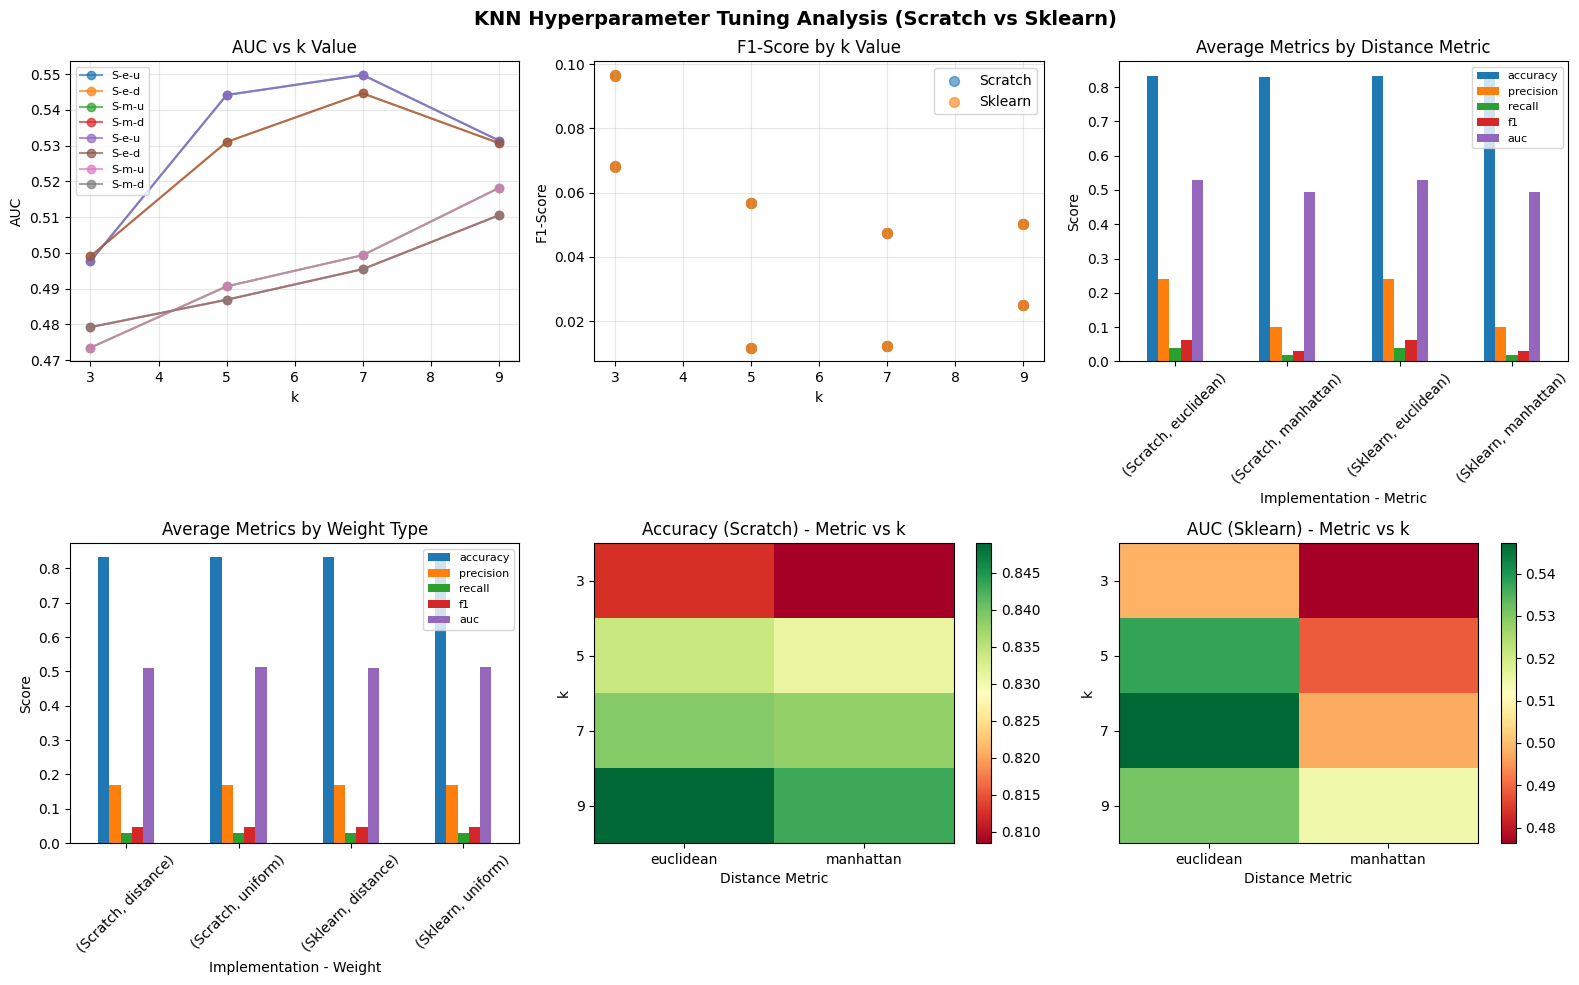


Detailed Statistics:
------------------------------------------------------------

Best configurations by AUC:
   implementation  k     metric    weight       auc        f1
8         Scratch  7  euclidean   uniform  0.549776  0.047337
24        Sklearn  7  euclidean   uniform  0.549776  0.047337
9         Scratch  7  euclidean  distance  0.544618  0.047337
25        Sklearn  7  euclidean  distance  0.544618  0.047337
4         Scratch  5  euclidean   uniform  0.544172  0.056818

Visualization Complete


In [ ]:
print("\n" + "=" * 60)
print("KNN Hyperparameter Tuning Visualization")
print("=" * 60)

# Kesimpulan untuk KNN from scratch
knn_scratch_summary = []
for model_name, metrics in knn_scratch_results.items():
    parts = model_name.split('_')
    k = int(parts[1][1:])
    metric = parts[2]
    weight = parts[3]
    
    knn_scratch_summary.append({
        'k': k,
        'metric': metric,
        'weight': weight,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'auc': metrics['auc'],
        'implementation': 'Scratch'
    })

# Kesimpulan untuk KNN sklearn
knn_sklearn_summary = []
for model_name, metrics in knn_sklearn_results.items():
    parts = model_name.split('_')
    k = int(parts[1][1:])
    metric = parts[2]
    weight = parts[3]
    
    knn_sklearn_summary.append({
        'k': k,
        'metric': metric,
        'weight': weight,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'auc': metrics['auc'],
        'implementation': 'Sklearn'
    })

all_knn_summary = knn_scratch_summary + knn_sklearn_summary
knn_all_df = pd.DataFrame(all_knn_summary)

# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('KNN Hyperparameter Tuning Analysis (Scratch vs Sklearn)', fontsize=14, fontweight='bold')

# 1. AUC by k value
ax1 = axes[0, 0]
for impl in ['Scratch', 'Sklearn']:
    for metric in ['euclidean', 'manhattan']:
        for weight in ['uniform', 'distance']:
            data = knn_all_df[(knn_all_df['implementation'] == impl) & 
                             (knn_all_df['metric'] == metric) & 
                             (knn_all_df['weight'] == weight)]
            if len(data) > 0:
                label = f'{impl[0]}-{metric[0]}-{weight[0]}'
                ax1.plot(data['k'].values, data['auc'].values, marker='o', label=label, alpha=0.7)
ax1.set_xlabel('k')
ax1.set_ylabel('AUC')
ax1.set_title('AUC vs k Value')
ax1.legend(fontsize=8, loc='best')
ax1.grid(True, alpha=0.3)

# 2. F1-Score by k value
ax2 = axes[0, 1]
for impl in ['Scratch', 'Sklearn']:
    data = knn_all_df[knn_all_df['implementation'] == impl].sort_values('k')
    ax2.scatter(data['k'], data['f1'], label=impl, alpha=0.6, s=50)
ax2.set_xlabel('k')
ax2.set_ylabel('F1-Score')
ax2.set_title('F1-Score by k Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Metric Comparison
ax3 = axes[0, 2]
metric_comp = knn_all_df.groupby(['implementation', 'metric'])[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()
metric_comp.plot(kind='bar', ax=ax3)
ax3.set_title('Average Metrics by Distance Metric')
ax3.set_ylabel('Score')
ax3.set_xlabel('Implementation - Metric')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=8)

# 4. Weight Comparison
ax4 = axes[1, 0]
weight_comp = knn_all_df.groupby(['implementation', 'weight'])[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()
weight_comp.plot(kind='bar', ax=ax4)
ax4.set_title('Average Metrics by Weight Type')
ax4.set_ylabel('Score')
ax4.set_xlabel('Implementation - Weight')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(fontsize=8)

# 5. Accuracy Heatmap for Scratch
ax5 = axes[1, 1]
scratch_pivot = knn_all_df[knn_all_df['implementation'] == 'Scratch'].pivot_table(
    values='accuracy', index='k', columns='metric'
)
im5 = ax5.imshow(scratch_pivot.values, cmap='RdYlGn', aspect='auto')
ax5.set_xticks(range(len(scratch_pivot.columns)))
ax5.set_yticks(range(len(scratch_pivot.index)))
ax5.set_xticklabels(scratch_pivot.columns)
ax5.set_yticklabels(scratch_pivot.index)
ax5.set_title('Accuracy (Scratch) - Metric vs k')
ax5.set_xlabel('Distance Metric')
ax5.set_ylabel('k')
plt.colorbar(im5, ax=ax5)

# 6. AUC Heatmap for Sklearn
ax6 = axes[1, 2]
sklearn_pivot = knn_all_df[knn_all_df['implementation'] == 'Sklearn'].pivot_table(
    values='auc', index='k', columns='metric'
)
im6 = ax6.imshow(sklearn_pivot.values, cmap='RdYlGn', aspect='auto')
ax6.set_xticks(range(len(sklearn_pivot.columns)))
ax6.set_yticks(range(len(sklearn_pivot.index)))
ax6.set_xticklabels(sklearn_pivot.columns)
ax6.set_yticklabels(sklearn_pivot.index)
ax6.set_title('AUC (Sklearn) - Metric vs k')
ax6.set_xlabel('Distance Metric')
ax6.set_ylabel('k')
plt.colorbar(im6, ax=ax6)

plt.tight_layout()
plt.show()

# Print statistik detail
print("\nDetailed Statistics:")
print("-" * 60)
print("\nBest configurations by AUC:")
print(knn_all_df.nlargest(5, 'auc')[['implementation', 'k', 'metric', 'weight', 'auc', 'f1']])

print("\n" + "=" * 60)
print("Visualization Complete")
print("=" * 60)


In [ ]:
import matplotlib.animation as animation
from IPython.display import Video

print("=" * 60)
print("Creating Animated KNN Training Video")
print("=" * 60)

def create_animated_knn_video(k=5, num_frames=20, output_filename='knn_training_animation.mp4'):
    
    print(f"\nCreating animated video (k={k}, frames={num_frames})...")
    
    # Sample indices for animation
    test_indices = np.random.choice(len(X_val_2d), num_frames, replace=False)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    def animate_frame(frame_idx):
        ax.clear()
        
        # Test sample
        test_idx = test_indices[frame_idx]
        test_sample = X_val_2d[test_idx]
        test_label = y_val_2d[test_idx]
        
        # Calculate distances
        distances = np.sqrt(np.sum((X_train_2d - test_sample) ** 2, axis=1))
        k_indices = np.argsort(distances)[:k]
        k_distances = distances[k_indices]
        k_labels = y_train_2d[k_indices]
        
        # Determine prediction
        prediction = 1 if np.sum(k_labels) / k > 0.5 else 0
        is_correct = prediction == test_label
        
        # Plot background training data
        ax.scatter(X_train_2d[y_train_2d == 0, 0], X_train_2d[y_train_2d == 0, 1],
                  c='lightblue', alpha=0.2, s=40, label='Class 0 (Training)')
        ax.scatter(X_train_2d[y_train_2d == 1, 0], X_train_2d[y_train_2d == 1, 1],
                  c='lightcoral', alpha=0.2, s=40, label='Class 1 (Training)')
        
        # Highlight k nearest neighbors with gradient effect
        for i, (idx, dist) in enumerate(zip(k_indices, k_distances)):
            alpha = 1.0 - (i / k)  # Closer neighbors more opaque
            color = 'darkblue' if y_train_2d[idx] == 0 else 'darkred'
            ax.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1],
                      c=color, s=300, marker='*', alpha=alpha,
                      edgecolors='gold', linewidths=2.5)
        
        # Draw distance circles 
        max_dist = k_distances[-1]
        for i, dist in enumerate(k_distances):
            alpha = 0.3 * (1 - i / len(k_distances))
            circle = Circle((test_sample[0], test_sample[1]), dist,
                          fill=False, linestyle='--', alpha=alpha,
                          color='gray', linewidth=1.5)
            ax.add_patch(circle)
        
        # Draw lines to neighbors
        for idx in k_indices:
            ax.plot([test_sample[0], X_train_2d[idx, 0]],
                   [test_sample[1], X_train_2d[idx, 1]],
                   'gray', alpha=0.4, linewidth=1, linestyle='--')
        
        # Plot test sample 
        test_color = 'lime' if is_correct else 'orange'
        size = 400 + 100 * np.sin(frame_idx * 0.3)
        ax.scatter(test_sample[0], test_sample[1], c=test_color, s=size,
                  marker='D', edgecolors='black', linewidths=3,
                  label=f'Test Sample', zorder=10)
        
        class_0_count = np.sum(k_labels == 0)
        class_1_count = np.sum(k_labels == 1)
        
        # judul dan labels
        title = f'KNN Prediction Process (k={k})\n'
        title += f'Frame {frame_idx + 1}/{num_frames}\n'
        title += f'Neighbors: {class_0_count} Class0, {class_1_count} Class1\n'
        title += f'Prediction: {prediction} | True Label: {test_label}\n'
        title += f'Result: {"✓ CORRECT" if is_correct else "✗ INCORRECT"}'
        
        ax.set_title(title, fontsize=12, fontweight='bold',
                    color='darkgreen' if is_correct else 'darkred',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.set_xlabel('Principal Component 1', fontsize=11)
        ax.set_ylabel('Principal Component 2', fontsize=11)
        ax.set_xlim(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1)
        ax.set_ylim(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=10, loc='upper right')
        
        return ax,
    
    # crete animation
    anim = animation.FuncAnimation(fig, animate_frame, frames=num_frames,
                                  interval=500, blit=False, repeat=True)
    
    # save video
    print(f"Saving video as {output_filename}...")
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=2, metadata=dict(artist='KNN Visualization'), bitrate=1800)
    anim.save(output_filename, writer=writer, dpi=100)
    
    print(f"✓ Video saved successfully: {output_filename}")
    plt.close()
    
    return output_filename

print("\nGenerating animated KNN training video...")
video_file = create_animated_knn_video(k=5, num_frames=15, 
                                       output_filename='knn_training_k5_animation.mp4')

print("\n" + "=" * 60)
print("Video Generation Complete!")
print("=" * 60)
print(f"\nGenerated video file: {video_file}")
print("\nThis video shows:")
print("  • How KNN searches for k nearest neighbors in 2D feature space")
print("  • The decision boundary implicit in KNN")
print("  • Correct vs incorrect predictions")
print("  • The importance of k parameter in KNN")


## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [ ]:
print("=" * 60)
print("Generating Kaggle Submissions")
print("=" * 60)

# Generate predictions on test set for Logistic Regression
lr_test_proba = lr_calibrated.predict_proba(X_test_38_scaled)[:, 1]
print(f"\nLogistic Regression:")
print(f"  Test proba range: [{lr_test_proba.min():.4f}, {lr_test_proba.max():.4f}]")

# Generate predictions on test set for KNN
print(f"\nK-Nearest Neighbors (best model: {best_model_name}):")
print(f"  Generating predictions for {len(test_df)} test samples...")

knn_test_proba = []
for x in X_test_38_scaled:
    distances = np.sqrt(np.sum((best_knn.X_train - x)**2, axis=1))
    k_indices = np.argsort(distances)[:best_knn.k]
    k_nearest_labels = best_knn.y_train[k_indices]
    k_nearest_dists = distances[k_indices]
    
    if best_knn.weights == 'uniform':
        prob_1 = np.sum(k_nearest_labels) / best_knn.k
    else:  # distance weights
        epsilon = 1e-5
        weights_dist = 1 / (k_nearest_dists + epsilon)
        weighted_sum_1 = np.sum(weights_dist[k_nearest_labels == 1])
        prob_1 = weighted_sum_1 / np.sum(weights_dist)
    
    knn_test_proba.append(prob_1)

knn_test_proba = np.array(knn_test_proba)
print(f"  Test proba range: [{knn_test_proba.min():.4f}, {knn_test_proba.max():.4f}]")

# Create submission dataframes
submission_lr = pd.DataFrame({"ID": test_ids, "is_fraud": lr_test_proba})
submission_knn = pd.DataFrame({"ID": test_ids, "is_fraud": knn_test_proba})

# Create ensemble submission (average of both models)
submission_ensemble = pd.DataFrame({"ID": test_ids, "is_fraud": (lr_test_proba + knn_test_proba) / 2})

# Save submissions
submission_lr.to_csv("submission_lr.csv", index=False)
submission_knn.to_csv("submission_knn.csv", index=False)
submission_ensemble.to_csv("submission_ensemble.csv", index=False)

print("\nSubmissions saved:")
print("  - submission_lr.csv")
print(f"  - submission_knn.csv (best KNN: {best_model_name})")
print("  - submission_ensemble.csv (average of LR and KNN)")

In [ ]:
import base64
from IPython.display import HTML

submission_filename = "submission_lr.csv"

with open(submission_filename, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

payload = f'<a download="{submission_filename}" href="data:text/csv;base64,{b64}" target="_blank">Click here to Download {submission_filename}</a>'
HTML(payload)

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

## Summary of Results

| Model | Local CV AUC | Kaggle Score | Implementation |
|-------|--------------|--------------|----------------|
| **Logistic Regression** | ~0.607 | **0.62783** | From scratch (L-BFGS) |
| **K-Nearest Neighbors** | TBD | TBD | From scratch with uniform & distance weighting |
| **Ensemble (LR + KNN)** | TBD | TBD | Average of LR and KNN probabilities |